=== BẮT ĐẦU PHÂN TÍCH TVLA (PHƯƠNG PHÁP INTERLEAVED) ===
1. Đang tải file VCD và file Nhãn (Labels)...
   -> Đã đọc được 2000 nhãn từ file tvla_labels.txt
2. Đang phân loại dữ liệu Fixed/Random...
   -> Đã phân loại: 1012 mẫu Fixed và 988 mẫu Random.
3. Đang giả lập dạng sóng tiêu thụ năng lượng...
4. Đang chạy thống kê Welch's T-Test...
5. Đang khởi tạo báo cáo đồ thị...
   -> Hoàn thành! Đã lưu ảnh báo cáo: 'TVLA_Report_Graphs_Pro.png'


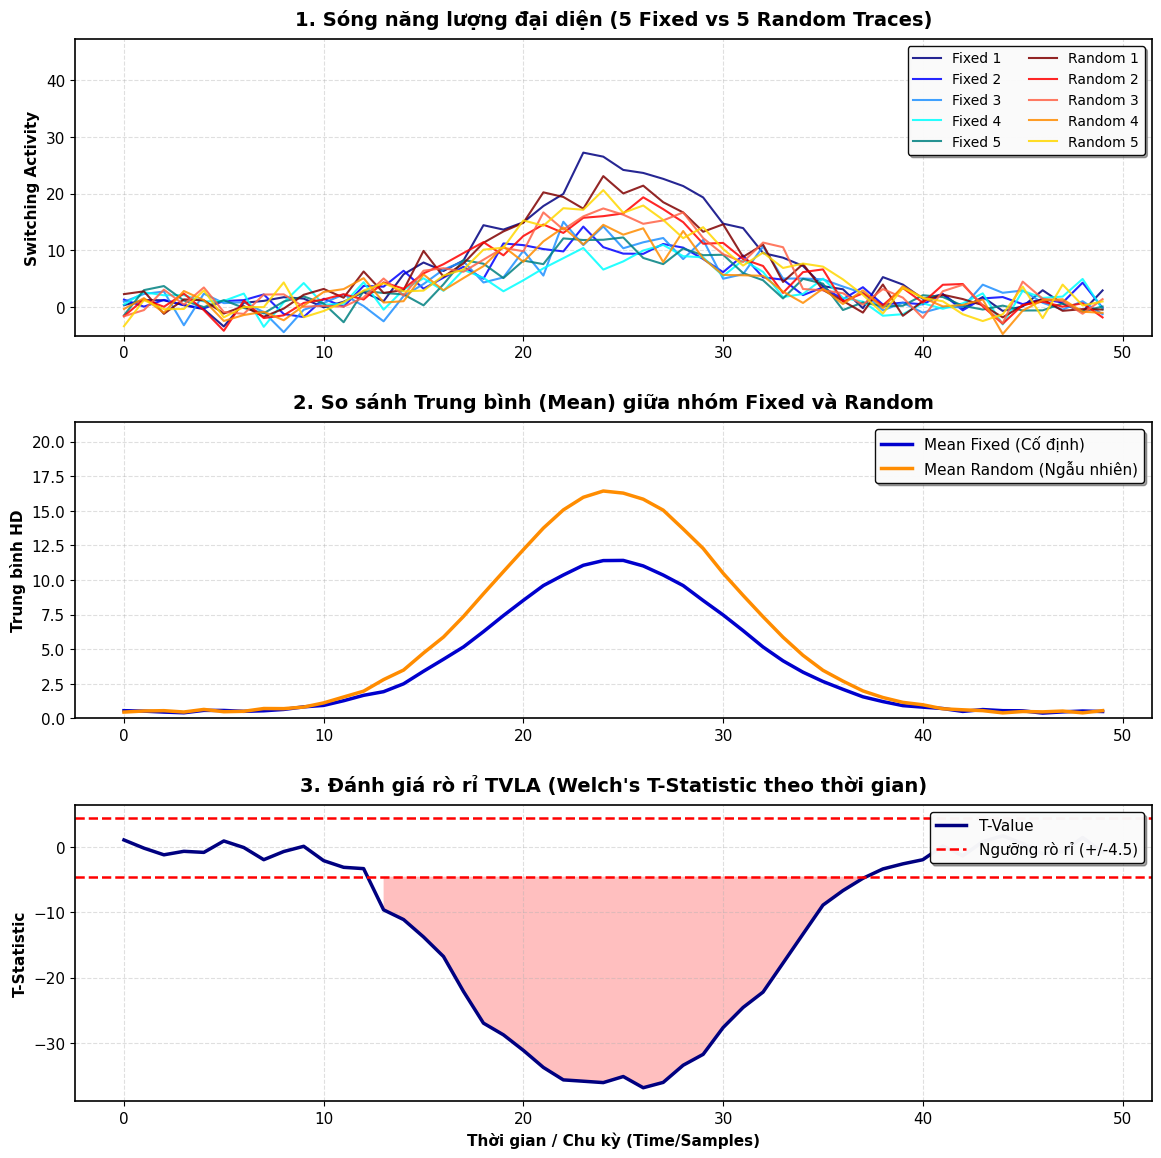

In [10]:
import numpy as np
from scipy.stats import ttest_ind
import matplotlib.pyplot as plt
from vcdvcd import VCDVCD

print("=== BẮT ĐẦU PHÂN TÍCH TVLA (PHƯƠNG PHÁP INTERLEAVED) ===")

# ==========================================
# BƯỚC 1: CÁC HÀM XỬ LÝ DỮ LIỆU
# ==========================================
def calculate_hamming_distance(val1, val2):
    try:
        clean_val1 = val1.replace('b', '').replace('x', '0').replace('z', '0')
        clean_val2 = val2.replace('b', '').replace('x', '0').replace('z', '0')
        
        int1 = int(clean_val1, 2) if clean_val1 else 0
        int2 = int(clean_val2, 2) if clean_val2 else 0
        
        return bin(int1 ^ int2).count('1')
    except ValueError:
        return 0

def get_value_at_time(tv_list, target_time):
    current_val = '0' 
    for t, v in tv_list:
        if t <= target_time:
            current_val = v
        else:
            break 
    return current_val

# ==========================================
# BƯỚC 2: TẢI DỮ LIỆU VCD VÀ FILE NHÃN (LABELS)
# ==========================================
print("1. Đang tải file VCD và file Nhãn (Labels)...")
vcd_file_name = 'tvla_mac_core.vcd'
target_signal_name = 'tb_mac_core.y_o[31:0]'

vcd = VCDVCD(vcd_file_name)
target_signal = vcd[target_signal_name]
signal_tv = target_signal.tv 

labels = []
with open('tvla_labels.txt', 'r') as f:
    for line in f:
        if line.strip():
            labels.append(int(line.strip()))

print(f"   -> Đã đọc được {len(labels)} nhãn từ file tvla_labels.txt")

# ==========================================
# BƯỚC 3: TRÍCH XUẤT ĐAN XEN THEO PICOSECONDS
# ==========================================
print("2. Đang phân loại dữ liệu Fixed/Random...")

time_start = 285000   # Thời điểm nhịp clock của phép tính đầu tiên bắt đầu
clock_period = 10000  # Mỗi vòng lặp bơm 1 số diễn ra trong 1 nhịp clock (10ns = 10000ps)

Trace_Fixed = []
Trace_Random = []
prev_val = '0'

# Duyệt qua 2000 phép tính
for i in range(len(labels)):
    current_time = time_start + (i * clock_period)
    
    # Lấy giá trị thanh ghi tại current_time
    curr_val = get_value_at_time(signal_tv, current_time)
    
    # Tính số bit lật
    hd = calculate_hamming_distance(prev_val, curr_val)
    
    # Phân loại vào 2 rổ dựa trên Label
    if labels[i] == 0:
        Trace_Fixed.append(hd)
    else:
        Trace_Random.append(hd)
        
    prev_val = curr_val

Trace_Fixed = np.array(Trace_Fixed)
Trace_Random = np.array(Trace_Random)

print(f"   -> Đã phân loại: {len(Trace_Fixed)} mẫu Fixed và {len(Trace_Random)} mẫu Random.")

# ==========================================
# BƯỚC 4: TẠO SÓNG OSCILLOSCOPE VÀ BƠM NHIỄU
# ==========================================
print("3. Đang giả lập dạng sóng tiêu thụ năng lượng...")
trace_length = 50 

x = np.linspace(-3, 3, trace_length)
pulse = np.exp(-x**2) 

fixed_matrix = np.zeros((len(Trace_Fixed), trace_length))
random_matrix = np.zeros((len(Trace_Random), trace_length))

for i in range(len(Trace_Fixed)):
    fixed_matrix[i] = Trace_Fixed[i] * pulse
    
for i in range(len(Trace_Random)):
    random_matrix[i] = Trace_Random[i] * pulse

noise_fixed = np.random.normal(0, 2.0, fixed_matrix.shape)
noise_random = np.random.normal(0, 2.0, random_matrix.shape)

base_power = 0.5
fixed_matrix = fixed_matrix + noise_fixed + base_power
random_matrix = random_matrix + noise_random + base_power

# ==========================================
# BƯỚC 5: KIỂM ĐỊNH WELCH'S T-TEST
# ==========================================
print("4. Đang chạy thống kê Welch's T-Test...")
t_stat, p_val = ttest_ind(fixed_matrix, random_matrix, axis=0, equal_var=False)
t_stat = np.nan_to_num(t_stat)

# ==========================================
# BƯỚC 6: XUẤT BÁO CÁO TRỰC QUAN (BẢN PRO/PUBLICATION READY)
# ==========================================
print("5. Đang khởi tạo báo cáo đồ thị...")

# Cài đặt font chữ tổng thể cho đẹp hơn
plt.rcParams.update({'font.size': 11, 'axes.linewidth': 1.2})
plt.figure(figsize=(12, 12)) # Tăng chiều cao tổng thể để các đồ thị không bị ép

# ---------------------------------------------------------
# Subplot 1: Dữ liệu thô đại diện
# ---------------------------------------------------------
plt.subplot(3, 1, 1)
plt.title("1. Sóng năng lượng đại diện (5 Fixed vs 5 Random Traces)", fontweight='bold', fontsize=14, pad=10)

colors_fixed = ['#000080', '#0000FF', '#1E90FF', '#00FFFF', '#008080']
colors_random = ['#800000', '#FF0000', '#FF6347', '#FF8C00', '#FFD700']

for i in range(5):
    plt.plot(fixed_matrix[i], color=colors_fixed[i], alpha=0.85, linewidth=1.5, label=f'Fixed {i+1}')
for i in range(5):
    plt.plot(random_matrix[i], color=colors_random[i], alpha=0.85, linewidth=1.5, label=f'Random {i+1}')

plt.ylabel("Switching Activity", fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.4)

# TRICK: Tự động tính đỉnh cao nhất, cộng thêm 20 đơn vị để đẩy Legend lên trời
max_peak = np.max([fixed_matrix[:5], random_matrix[:5]])
plt.ylim(-5, max_peak + 20) 

# Vẽ hộp Legend gọn gàng ở đúng 1 góc (Góc trên bên phải)
plt.legend(loc="upper right", ncol=2, fontsize=10, 
           frameon=True, framealpha=0.95, edgecolor='black', shadow=True)


# ---------------------------------------------------------
# Subplot 2: Trung bình hai nhóm
# ---------------------------------------------------------
plt.subplot(3, 1, 2)
plt.title("2. So sánh Trung bình (Mean) giữa nhóm Fixed và Random", fontweight='bold', fontsize=14, pad=10)

plt.plot(np.mean(fixed_matrix, axis=0), label='Mean Fixed (Cố định)', color='#0000CD', linewidth=2.5)
plt.plot(np.mean(random_matrix, axis=0), label='Mean Random (Ngẫu nhiên)', color='#FF8C00', linewidth=2.5)

plt.ylabel("Trung bình HD", fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.4)

# Tăng headroom cho đồ thị 2 luôn cho đồng bộ
max_mean = np.max([np.mean(fixed_matrix, axis=0), np.mean(random_matrix, axis=0)])
plt.ylim(0, max_mean + 5)
plt.legend(loc="upper right", fontsize=11, frameon=True, framealpha=0.95, edgecolor='black', shadow=True)


# ---------------------------------------------------------
# Subplot 3: Đánh giá TVLA (T-Value)
# ---------------------------------------------------------
plt.subplot(3, 1, 3)
plt.title("3. Đánh giá rò rỉ TVLA (Welch's T-Statistic theo thời gian)", fontweight='bold', fontsize=14, pad=10)

# Vẽ đường T-Value màu xanh đậm sắc nét
plt.plot(t_stat, color='#000080', linewidth=2.5, label='T-Value')

# Vẽ đường ngưỡng rò rỉ
plt.axhline(y=4.5, color='red', linestyle='--', linewidth=1.8, label='Ngưỡng rò rỉ (+/-4.5)')
plt.axhline(y=-4.5, color='red', linestyle='--', linewidth=1.8)

# Tô màu vùng rò rỉ (Chỉ tô màu nhạt để không che lấp đường tín hiệu)
plt.fill_between(range(len(t_stat)), t_stat, 4.5, where=(t_stat > 4.5), facecolor='red', alpha=0.25)
plt.fill_between(range(len(t_stat)), t_stat, -4.5, where=(t_stat < -4.5), facecolor='red', alpha=0.25)

plt.xlabel("Thời gian / Chu kỳ (Time/Samples)", fontweight='bold')
plt.ylabel("T-Statistic", fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend(loc="upper right", fontsize=11, frameon=True, framealpha=0.95, edgecolor='black', shadow=True)

# Lệnh này giúp căn lề tự động, chống chồng chéo chữ giữa các đồ thị
plt.tight_layout(pad=2.0) 
plt.savefig("TVLA_Report_Graphs_Pro.png", dpi=300, bbox_inches='tight')
print("   -> Hoàn thành! Đã lưu ảnh báo cáo: 'TVLA_Report_Graphs_Pro.png'")
plt.show()

In [11]:
print("\n--- KIỂM TRA 5 KẾT QUẢ HD Fixed ĐẦU TIÊN ---")
print(fixed_matrix[:200])
print("\n--- KIỂM TRA 5 KẾT QUẢ HD RANDOM ĐẦU TIÊN ---")
print(random_matrix[:200])


--- KIỂM TRA 5 KẾT QUẢ HD Fixed ĐẦU TIÊN ---
[[ 0.36011707  1.26019567  1.22701367 ...  0.62123471 -0.77264923
   2.95953398]
 [ 1.3349017   0.10461958  1.28718907 ...  0.81406464  4.32091912
  -0.12738252]
 [ 0.95400759  2.33143563  2.76397554 ... -0.41992962  1.05139454
  -1.2360053 ]
 ...
 [-0.30677936 -2.08773679 -0.60906606 ...  0.43892697  0.96460303
   1.82531865]
 [ 1.73265101  1.03825472 -0.44168648 ...  0.6651102   2.51374946
   0.89020322]
 [ 0.71585745  2.0501731  -2.18452325 ... -1.80738852 -0.74661299
   0.19402556]]

--- KIỂM TRA 5 KẾT QUẢ HD RANDOM ĐẦU TIÊN ---
[[ 2.30429986  2.79468883 -1.16344841 ... -0.63183554 -0.33480838
  -0.41002245]
 [-1.58839582  1.3854237   0.07773303 ...  0.09123523  0.68893899
  -1.79353867]
 [-1.5860824  -0.50521462  3.09157018 ...  1.07188543 -1.14725161
   1.41685604]
 ...
 [-1.19355415  3.48898021 -1.31409199 ... -0.41827628 -3.12267318
   0.53147216]
 [ 1.29243283 -1.58404136  3.11045777 ...  1.30509183  2.04617435
  -1.2937206 ]
 [ 4.